# To Steer or Not To Steer

How should Sebastian find the island?

![](https://raw.githubusercontent.com/mcabbott/ToSteerOrNot.jl/refs/heads/master/docs/sebastian.png)

This notebook has code related to "Discrete turn strategies emerge in information-limited navigation" by Jose M. Betancourt, Matthew P. Leighton, Thierry Emonet, Benjamin B. Machta, Michael C. Abbott, [arxiv:2602.23324](https://arxiv.org/abs/2602.23324).

The repository is here: [github.com/mcabbott/ToSteerOrNot.jl](https://github.com/mcabbott/ToSteerOrNot.jl)

## Jupyter notebook

This is not a reactive notebook. If you edit any cell and pressing shift-enter to run it, you will have to re-run any later cells to see the effect.

If running on google Colab, you may need to select "Runtime > Change runtime type > Julia".

In [1]:
VERSION  # we need Julia >= 1.11, and Colab provides 1.12 at present

v"1.12.6"

In [2]:
import Pkg; Pkg.add(url="https://github.com/mcabbott/ToSteerOrNot.jl")  # will take a minute!

    Updating git-repo `https://github.com/mcabbott/ToSteerOrNot.jl`
   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [c95c5c81] ~ ToSteerOrNot v0.1.0 `https://github.com/mcabbott/ToSteerOrNot.jl#master` ⇒ v0.1.0 `https://github.com/mcabbott/ToSteerOrNot.jl#master`
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [c95c5c81] ~ ToSteerOrNot v0.1.0 `https://github.com/mcabbott/ToSteerOrNot.jl#master` ⇒ v0.1.0 `https://github.com/mcabbott/ToSteerOrNot.jl#master`
Precompiling packages...
  13748.4 ms  ✓ ToSteerOrNot
  1 dependency successfully precompiled in 18 seconds. 513 already precompiled.


In [3]:
using ToSteerOrNot  # just installed
using DelimitedFiles  # standard library
using Plots  # package, may prompt to install

In [4]:
Plots.default(titlefontsize=12)

In [5]:
mytitle(nt::NamedTuple) = string(map(x -> round(x; sigdigits=2), nt[(:info, :speed, :gamma)]))

mytitle (generic function with 1 method)

## Figure 2: some simple solutions

There are many functions like `maxABC(gamma, n)` which maximise ``v-γi``, with ``θ`` discretised in `n` steps.
Each such function returns a `NamedTuple` with `.speed`, `.info`, a vector `.prob`, and all sorts of other info.

The examples here all have ``γ`` chosen to make ``i≈0.1``.

In [6]:
begin
    # tum01 = max2Wtumble(0.76, 36)  # crude function
    tum01 = max2Wcostumble(0.76, 36)  # more refined one using trig basis
end

(objective = 0.0804189699712654, speed = 0.1570139251098113, info = 0.10078283570861303, gamma = 0.76, prob = [0.0366018761051815, 0.03646476262884565, 0.03605762630538752, 0.03539302285005088, 0.03449166910665935, 0.033382060519318385, 0.0320998132849122, 0.030686645004614644, 0.029188936065725545, 0.02765587771114951  …  0.026137304752307435, 0.027655877711149534, 0.029188936065725566, 0.03068664500461466, 0.032099813284912224, 0.033382060519318385, 0.03449166910665935, 0.03539302285005089, 0.03605762630538752, 0.03646476262884564], lambda = [0.5201379907411298, 0.5258786169493321, 0.5432475945602535, 0.5726640729837797, 0.6147502692173876, 0.6702094865916942, 0.7396454768037604, 0.8233242831880548, 0.9208939026440094, 1.031097038367995  …  1.1515318358765418, 1.0310970383679952, 0.9208939026440097, 0.8233242831880551, 0.7396454768037604, 0.6702094865916943, 0.6147502692173875, 0.57266407298378, 0.5432475945602535, 0.5258786169493321], tau = nothing, eta = true, coscoeff = [1.1152676

In [7]:
mytitle(tum01)  # utility for plot titles

"(info = 0.1, speed = 0.16, gamma = 0.76)"

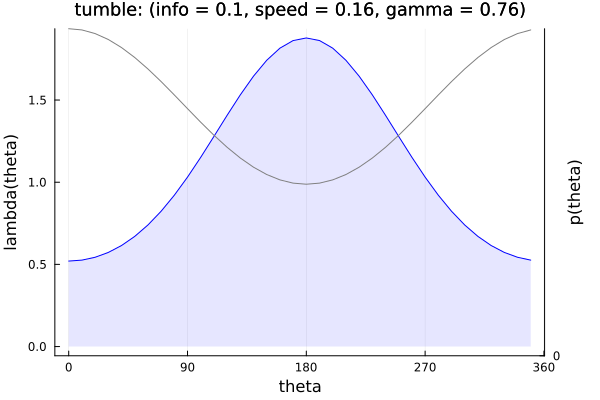

In [8]:
let sol = tum01
    p = plot(0:10:350, sol.lambda, xguide="theta", yguide="lambda(theta)", c=:blue, fill=0, fillalpha=0.1)
    plot!(twinx(p), 0:10:350, sol.prob, yguide="p(theta)\n", yticks=[0], ylims=[0,:auto], c=:grey)
    plot!(p, title="tumble: " * mytitle(sol), legend=false, xticks=0:90:360)
end

In [9]:
begin
    rev01 = max2Wcosreverse(1.03, 36)
    ste01 = max2Wsinsteer(1.03, 36)
    abs01 = max2Wcosabs(0.55, 36)
end

(objective = 0.05712554362708839, speed = 0.11370755852468188, info = 0.10287639072289725, gamma = 0.55, prob = [0.03401167255126905, 0.032394550320249536, 0.03070217976571719, 0.029017266190668464, 0.02740534455058387, 0.025913145240359328, 0.024570262053762903, 0.02339265616704467, 0.022386668409696633, 0.021552701524283586  …  0.03242243720492541, 0.03400972810401828, 0.03543251699443405, 0.03660437250877633, 0.03744519961704237, 0.03789114484037313, 0.03790403517334058, 0.03747826325157632, 0.036643134111865656, 0.03545959439359895], mu = [0.895810172787024, 0.9139105088784594, 0.9670704454116731, 1.0520493711731145, 1.1639887787192886, 1.297046345154383, 1.4450187243441772, 1.6018312508994113, 1.7618656344147476, 1.9201217545442864  …  2.0722647281342725, 1.9201217545442866, 1.761865634414748, 1.6018312508994117, 1.4450187243441772, 1.2970463451543834, 1.163988778719289, 1.0520493711731147, 0.9670704454116731, 0.9139105088784594], signed = false, coscoeff = [1.8675830179497468, -0

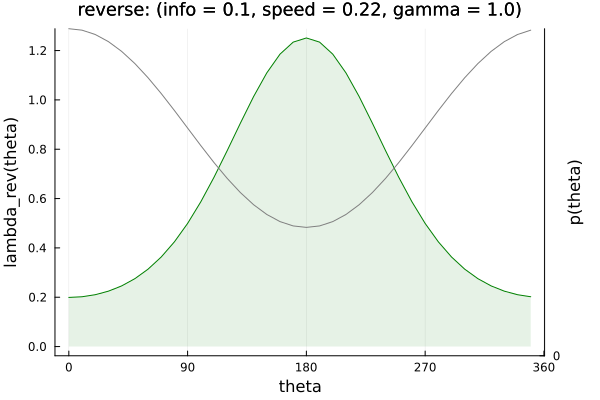

In [10]:
let sol = rev01
    p = plot(0:10:350, sol.zeta, xguide="theta", yguide="lambda_rev(theta)", c=:green, fill=0, fillalpha=0.1)
    plot!(twinx(p), 0:10:350, sol.prob, yguide="p(theta)\n", yticks=[0], ylims=[0,:auto], c=:grey)
    plot!(p, title="reverse: " * mytitle(sol), legend=false, xticks=0:90:360)
end

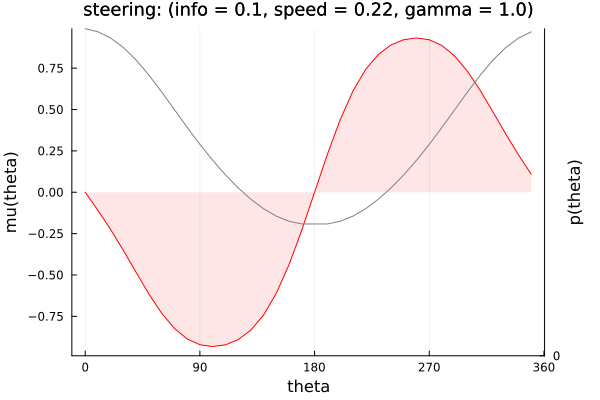

In [11]:
let sol = ste01
    p = plot(0:10:350, sol.mu, xguide="theta", yguide="mu(theta)", c=:red, fill=0, fillalpha=0.1)
    plot!(twinx(p), 0:10:350, sol.prob, yguide="p(theta)\n", yticks=[0], ylims=[0,:auto], c=:grey)
    plot!(p, title="steering: " * mytitle(sol), legend=false, xticks=0:90:360)
end

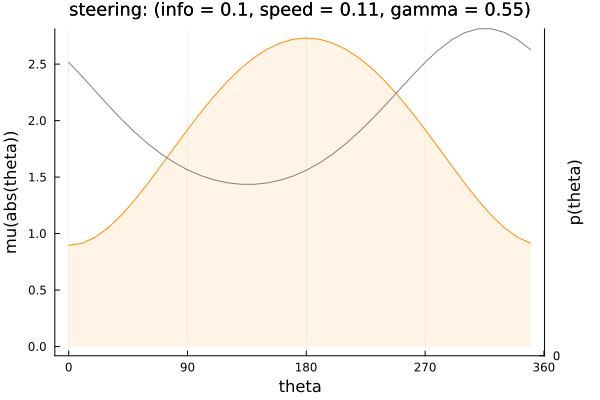

In [12]:
let sol = abs01
    p = plot(0:10:350, sol.mu, xguide="theta", yguide="mu(abs(theta))", c=:darkorange, fill=0, fillalpha=0.1)
    plot!(twinx(p), 0:10:350, sol.prob, yguide="p(theta)\n", yticks=[0], ylims=[0,:auto], c=:grey)
    plot!(p, title="steering: " * mytitle(sol), legend=false, xticks=0:90:360)
end

## Figure 1: performance curves speed-vs-info

We just need to run the functions above many times.

For the case of steering, we have an exact analytic solution too,
and load evaluations of this from a CSV file.

In [13]:
tumble40 = [max2Wcostumble(γ) for γ in logrange(0.001, 2, 40)]

40-element Vector{@NamedTuple{objective::Float64, speed::Float64, info::Float64, gamma::Float64, prob::Vector{Float64}, lambda::Vector{Float64}, tau::Nothing, eta::Bool, coscoeff::Vector{Float64}, positive::@NamedTuple{coscoeff::Nothing}, length::Int64, calls::Int64, time::Float64}}:
 (objective = 0.8603842657379186, speed = 0.909764156733119, info = 49.37989099520033, gamma = 0.001, prob = [0.07207146045507438, 0.07137602669608253, 0.06928972541910698, 0.06581255662414767, 0.06094452031120468, 0.05468561648027797, 0.04703584513136754, 0.037995206264473384, 0.027563699879595515, 0.015741325976733934  …  0.006402615259725087, 0.015741325976733913, 0.027563699879595498, 0.03799520626447336, 0.04703584513136752, 0.05468561648027794, 0.06094452031120466, 0.06581255662414766, 0.06928972541910694, 0.0713760266960825], lambda = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 32.32087059671913  …  134.32703411896196, 32.320870596719416, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], tau = nothing, eta

In [14]:
reverse30 = [max2Wcosreverse(γ) for γ in logrange(0.001, 1.5, 30)];
steer40 = [max2Wsinsteer(γ) for γ in logrange(0.001, 2, 40)];
evensteerd40 = [max2Wcosabs(γ) for γ in logrange(0.0005, 2, 40)];

┌ Info: zero eigenvalue (iter 3) is:
└   val = -2.6297732874149345e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 2.165418212519134e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.1467469801666623e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0994020673905827e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0456739118829656e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.067107766585906e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0617475678067705e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0814850692383356e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0818179271059342e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 2.388402617027045e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0145225655233619e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 8.365209232228999e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.2827212547458218e-10
┌ Info: zero eigenvalue (iter 3) is:
└   val = 1.0531043855892013e-10
┌ Info: zero eigenvalue

In [15]:
steer_exact = DelimitedFiles.readdlm(joinpath(pkgdir(ToSteerOrNot), "docs/Analytic_Frontier_Points.csv"), ' ')

1100×3 Matrix{Float64}:
   1.1749e-5   0.997576    206.043
   1.19208e-5  0.997559    204.551
   1.20952e-5  0.997541    203.069
   1.22721e-5  0.997523    201.599
   1.24515e-5  0.997505    200.139
   1.26336e-5  0.997487    198.689
   1.28184e-5  0.997468    197.25
   1.30059e-5  0.99745     195.821
   1.31961e-5  0.997431    194.403
   1.33891e-5  0.997413    192.995
   1.35849e-5  0.997394    191.597
   1.37836e-5  0.997375    190.21
   1.39852e-5  0.997356    188.832
   ⋮                       
  85.2387      0.00293292    1.72041e-5
  86.4854      0.00289064    1.67117e-5
  87.7503      0.00284897    1.62334e-5
  89.0336      0.00280791    1.57687e-5
  90.3358      0.00276743    1.53174e-5
  91.657       0.00272754    1.4879e-5
  92.9975      0.00268823    1.44532e-5
  94.3576      0.00264948    1.40395e-5
  95.7377      0.00261129    1.36377e-5
  97.1379      0.00257365    1.32474e-5
  98.5585      0.00253655    1.28682e-5
 100.0         0.00249999    1.24999e-5

In [16]:
function myscatter!(xs::Vector; m=:circle, c=colour2(xs[1]), lab="", kw...)
    scatter!(getfield.(xs, :info), getfield.(xs, :speed); m, c, lab, fill=NaN, kw...)
end

myscatter! (generic function with 1 method)

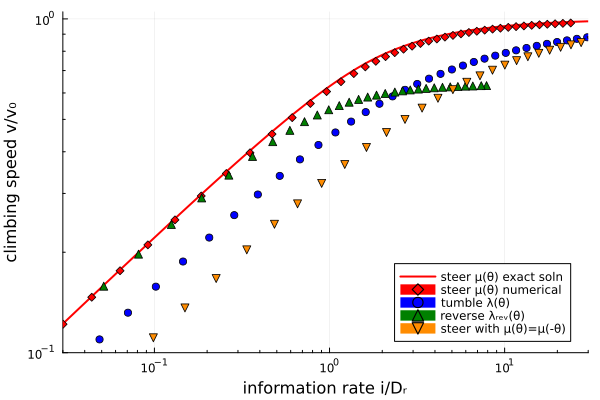

In [17]:
let
    plot(xguide="information rate i/Dᵣ", yguide="climbing speed v/v₀")

    plot!(steer_exact[:,3], steer_exact[:,2], c=:red, l=2, lab="steer μ(θ) exact soln")

    myscatter!(steer40, lab="steer μ(θ) numerical", m=:diamond)

    myscatter!(tumble40, lab="tumble λ(θ)")

    myscatter!(reverse30, m=:uptri, lab="reverse λᵣₑᵥ(θ)")

    myscatter!(evensteerd40, m=:downtri, lab="steer with μ(θ)=μ(-θ)")

    # axes
    plot!(xaxis=:log10, yaxis=:log10, minorticks=true)
    plot!(xlims=[0.03, 30], ylims=[0.1, 1.05])
    plot!(legend=:bottomright)
end

## Figure 3: discrete optimal strategies

Here `max2Wjump` is a fairly straightforward naiive optimisation of about `n^2` values -- plotted as a histogram here. However, `signed=false, mirror=true` imposes symmetry in both directions (optimising about `n^2 / 4` independent values).

The function `max2Wpair` uses some of what we know analytically, to find cleaner solutions.

In [18]:
simple_sym = max2Wjump(0.05, 36; signed=false, mirror=true)  # impose symmetry

(objective = 0.5516495577137731, speed = 0.7158438822434976, info = 3.283886490594489, gamma = 0.05, prob = [0.08513896501998178, 0.08189211354872154, 0.07571896807476336, 0.06791703675013207, 0.059321212472909925, 0.05027657052225106, 0.04088803156368032, 0.031230869215246197, 0.02157370686681207, 0.011916544518377948  …  0.0062543766034688026, 0.011916544518377934, 0.02157370686681205, 0.03123086921524618, 0.0408880315636803, 0.05027657052225103, 0.059321212472909876, 0.06791703675013204, 0.07571896807476332, 0.08189211354872152], jump = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], n = 36, tau2 = nothing, eta = true, signed = false, mirror = true, jump_raw = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 37.398384160431995 38.347626789045094], positive = (jump_raw = +,), length = 342, calls = 7385, time = 14.3)

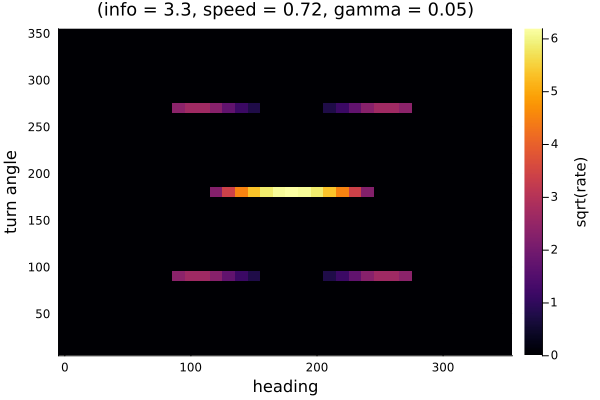

In [19]:
heatmap(0:10:350, 10:10:350, sqrt.(simple_sym.jump),
        xguide="heading", yguide="turn angle",
        title=mytitle(simple_sym),
        colorbar_title="sqrt(rate)")

In [20]:
simple_nosym = max2Wjump(0.05, 36; signed=true, mirror=false)  # without symmetry

(objective = 0.6769815383787913, speed = 0.8326475133562757, info = 3.1133194995496893, gamma = 0.05, prob = [0.11444527473261215, 0.11003374276129788, 0.09767039794568295, 0.07955547430419473, 0.05937429075339431, 0.04090772004661234, 0.025752661803871806, 0.014803756037353842, 0.007842378126951982, 0.0038445129632917394  …  0.0017621957038726028, 0.003840447233005095, 0.007835220925943936, 0.014790959567676013, 0.025725517289398772, 0.040867239207342254, 0.05932436474591324, 0.07949615473657244, 0.09762737325378626, 0.1100139477666921], jump = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], n = 36, tau2 = nothing, eta = true, signed = true, mirror = false, jump_raw = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], positive = (jump_raw = +,), length = 1260, calls = 106217, time = 96.9)

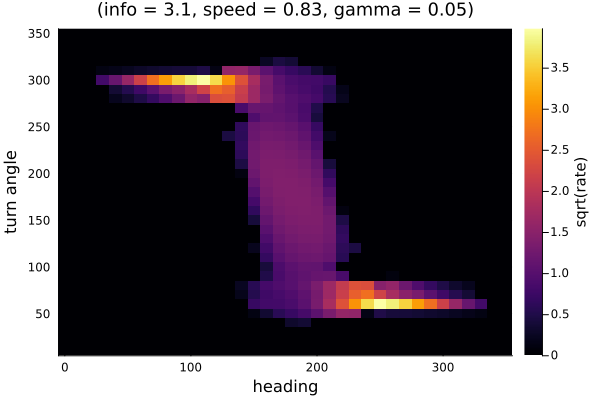

In [21]:
heatmap(0:10:350, 10:10:350, sqrt.(simple_nosym.jump),
        xguide="heading", yguide="turn angle",
        title=mytitle(simple_nosym),
        colorbar_title="sqrt(rate)")

In [22]:
pair2 = max2Wpair(0.05, 72; log=true)  # ncier version, with symmetry

(objective = 0.5773248369244147, speed = 0.7410519403395079, info = 3.274542068301865, gamma = 0.05, prob = [0.04548420916547933, 0.04517023467422792, 0.044249096170231664, 0.04277933502863552, 0.04084647519227894, 0.03854786227043801, 0.03597764577376031, 0.03321637298585056, 0.030327191843320278, 0.027357897593559912  …  0.024346705108748787, 0.027357897593559753, 0.03032719184332013, 0.033216372985850416, 0.035977645773760177, 0.0385478622704379, 0.04084647519227887, 0.04277933502863544, 0.04424909617023161, 0.04517023467422789], jump = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], lambda = [0.015160623206869318, 0.015521021127902277, 0.016679637704250738, 0.01890179275788036, 0.022743667497028816, 0.02927597904362173, 0.04055452416860752, 0.06053910306228236, 0.09688271934706597, 0.1641197555828902  …  0.28884677727404595, 0.1641197555828902, 0.09688271934706597, 0.06053910306228236, 0.04055452416860752, 0.02927597904362173, 0.022743667497028816,

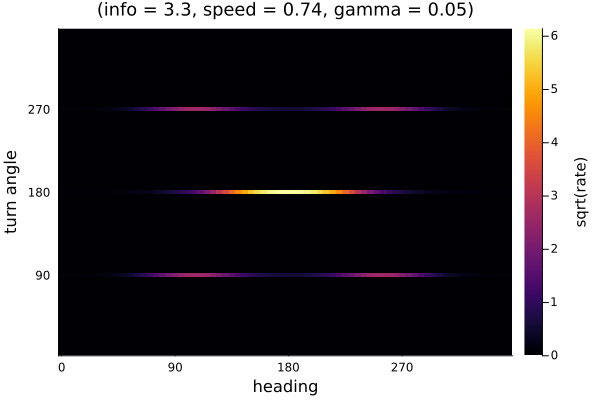

In [23]:
heatmap(0:5:355, 5:5:355, sqrt.(pair2.jump),
        xguide="heading", yguide="turn angle", xticks=0:90:360, yticks=0:90:360,
        title=mytitle(pair2),
        colorbar_title="sqrt(rate)")

In [24]:
pair3 = max2Wpair(0.005, 72; log=true, iterations=3000, g_abstol=1e-10)

(objective = 0.8313583361728574, speed = 0.9087680510656932, info = 15.48194297856717, gamma = 0.005, prob = [0.07990137959622136, 0.07838205881846563, 0.0740167446418902, 0.06736198276542005, 0.059142920789062296, 0.050010204537315694, 0.04048650188127847, 0.031007790797263683, 0.02207336411982108, 0.014389131100523313  …  0.008621288242213882, 0.01438913110052332, 0.022073364119821078, 0.03100779079726368, 0.04048650188127847, 0.05001020453731569, 0.05914292078906226, 0.06736198276542, 0.07401674464189018, 0.07838205881846562], jump = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], lambda = [0.014837191739858502, 0.016948556068125512, 0.02505519137671954, 0.046661865150574716, 0.10541124795629922, 0.2804767051534891, 0.8496681862787063, 2.680242924828758, 7.661565686011898, 17.65957422744279  …  31.203054456110166, 17.65957422744279, 7.661565686011898, 2.680242924828758, 0.8496681862787063, 0.2804767051534891, 0.10541124795629922, 0.04666186515057471

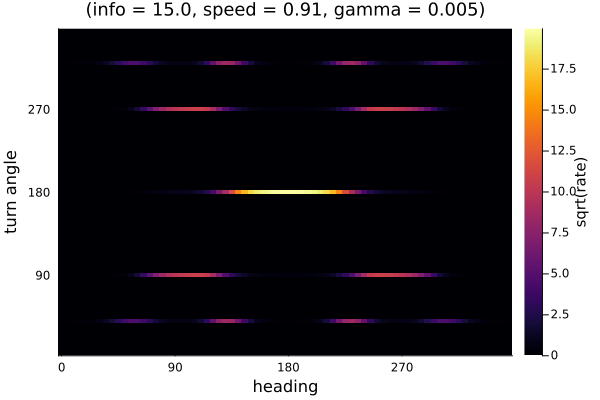

In [25]:
heatmap(0:5:355, 5:5:355, sqrt.(pair3.jump),
        xguide="heading", yguide="turn angle", xticks=0:90:360, yticks=0:90:360,
        title=mytitle(pair3),
        colorbar_title="sqrt(rate)")

## Figure 2E + 3C: some sample trajectories

There's a function `trajectory(rev01, 0:0.01:50)` which accepts the `NamedTuple` from optimisation, and a list of times, and integrates a random trajectory with diffusion plus (in this case) reverses as necessary.

That is called by `trajplot(rev01, 0:0.01:50, 1)` which plots 1 such trace nicely. It has different cases for different strategies, marking tumbles in blue, and reverasl by alternating light and dark green. Steering solutions are light/dark for left/right control.

Here we use the same solutions found above, all with ``i≈0.1``. Each time you run this (shift-enter on a cell) you will get a new random path.

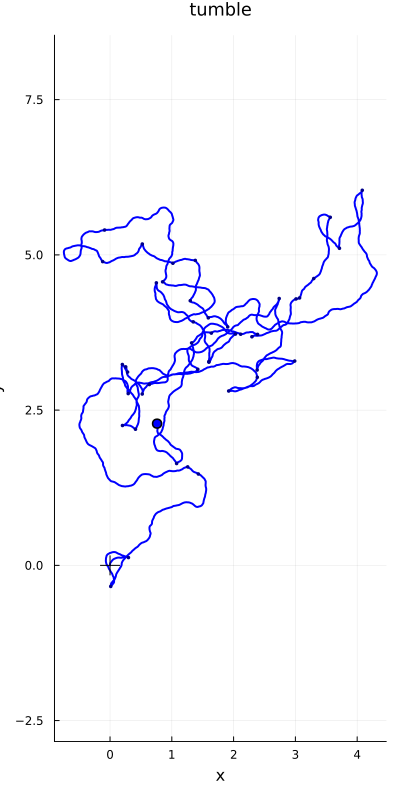

In [26]:
trajplot(tum01, 0:0.01:50, 1; limit=5, lab="", ms=5, msw=2, l=2, title="tumble")

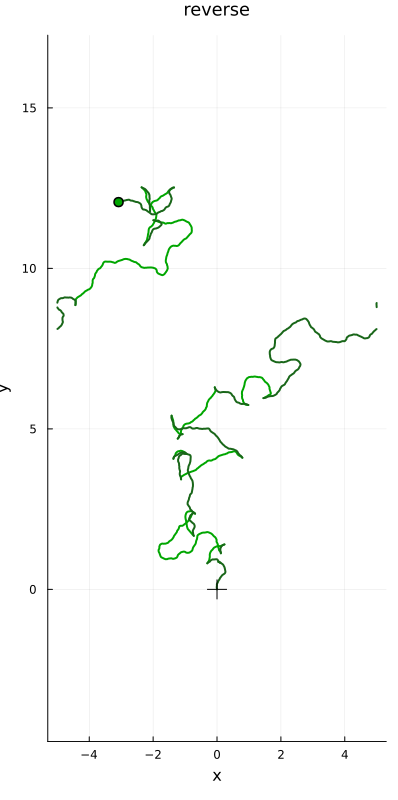

In [27]:
trajplot(rev01, 0:0.01:50, 1; limit=5, lab="", ms=5, msw=2, l=2, title="reverse")

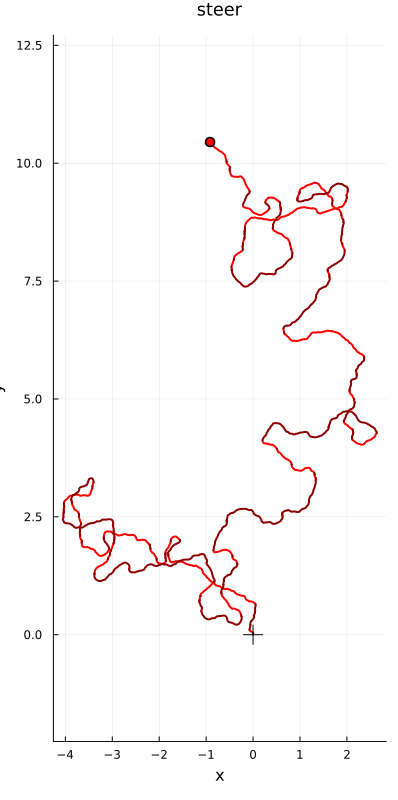

In [28]:
trajplot(ste01, 0:0.01:50, 1; limit=5, lab="", ms=5, msw=2, l=2, title="steer")

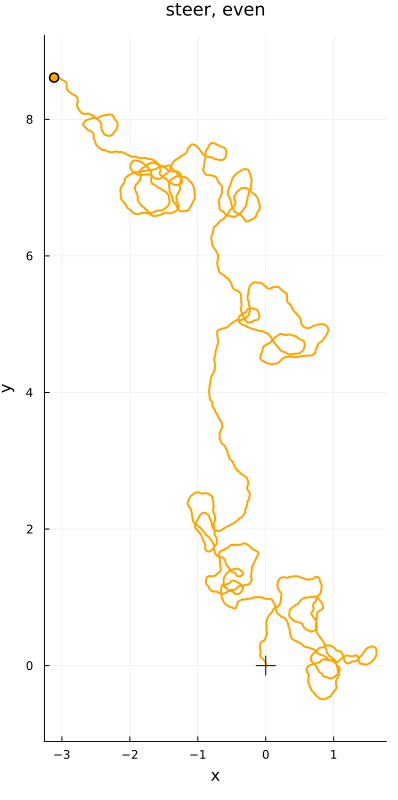

In [29]:
trajplot(abs01, 0:0.01:50, 1; limit=5, lab="", ms=5, msw=2, l=2, title="steer, even")

### more complex solutions

Now look at a discrete turn solution. This is at a higher information rate than above. And each plot shows three trajectories, starting from the same point.

Notice that most reverses (green triangles) occur just after a turn by +-90 degrees (purple), in cases where the 90 degree turn happened to go the wrong way.

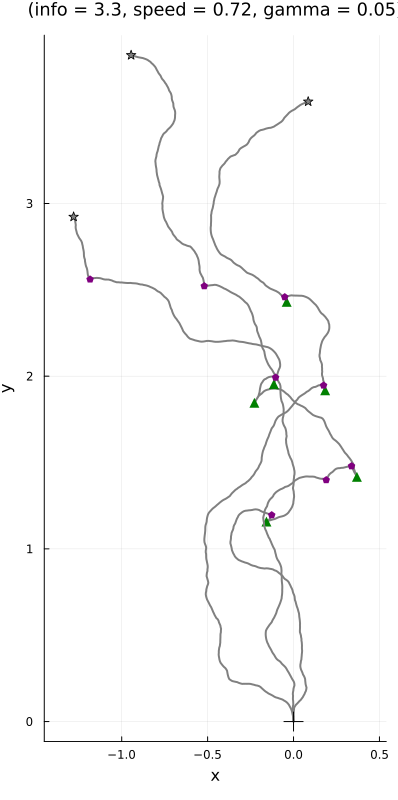

In [34]:
trajplot(simple_sym, 0:0.01:5, 3; limit=5, lab="", ms=5, m=:star, l=2, title=mytitle(simple_sym))  # even solution, turns left/right with equal prob.

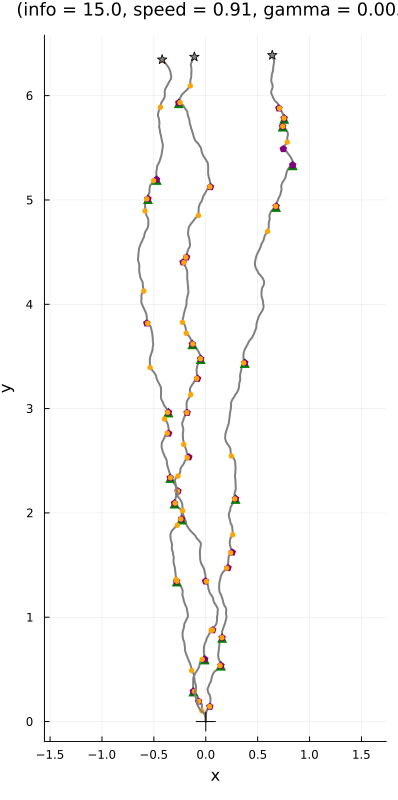

In [35]:
trajplot(pair3, 0:0.002:7, 3; limit=5, lab="", ms=5, m=:star, l=2, title=mytitle(pair3))  # three kinds of turns